# OISST AVHRR v02r01 - March 15, 2026 Preliminary


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.optim import Adam
import sys
sys.path.append('..')
from efgpnd import EFGPND
from load_oisst import load_oisst_grid, load_oisst_torch
from utils.ski import fit_ski_gp


In [4]:
DATASET_FILENAME = 'oisst-avhrr-v02r01.20260315_preliminary.nc'

lon_grid, lat_grid, sst_grid, sst_meta = load_oisst_grid(path=DATASET_FILENAME)
_, _, anom_grid, anom_meta = load_oisst_grid(variable='anom', path=DATASET_FILENAME)
_, _, ice_grid, ice_meta = load_oisst_grid(variable='ice', path=DATASET_FILENAME)

obs_date = sst_meta['date']
date_str = obs_date.strftime('%Y-%m-%d') if obs_date is not None else 'unknown'
valid_sst = np.isfinite(sst_grid)

print(f"Date: {date_str}")
print(f"lon_grid shape: {lon_grid.shape}")
print(f"lat_grid shape: {lat_grid.shape}")
print(f"sst_grid shape: {sst_grid.shape}")
print(f"Valid SST pixels: {valid_sst.sum():,}")
print(f"Lon range: {lon_grid.min():.3f} to {lon_grid.max():.3f}")
print(f"Lat range: {lat_grid.min():.3f} to {lat_grid.max():.3f}")
print(f"SST range: {np.nanmin(sst_grid):.2f} to {np.nanmax(sst_grid):.2f} {sst_meta['units']}")
print(f"Anomaly range: {np.nanmin(anom_grid):.2f} to {np.nanmax(anom_grid):.2f} {anom_meta['units']}")


Date: 2026-03-15
lon_grid shape: (720, 1440)
lat_grid shape: (720, 1440)
sst_grid shape: (720, 1440)
Valid SST pixels: 691,150
Lon range: -179.875 to 179.875
Lat range: -89.875 to 89.875
SST range: -1.80 to 31.28 Celsius
Anomaly range: -8.36 to 8.58 Celsius


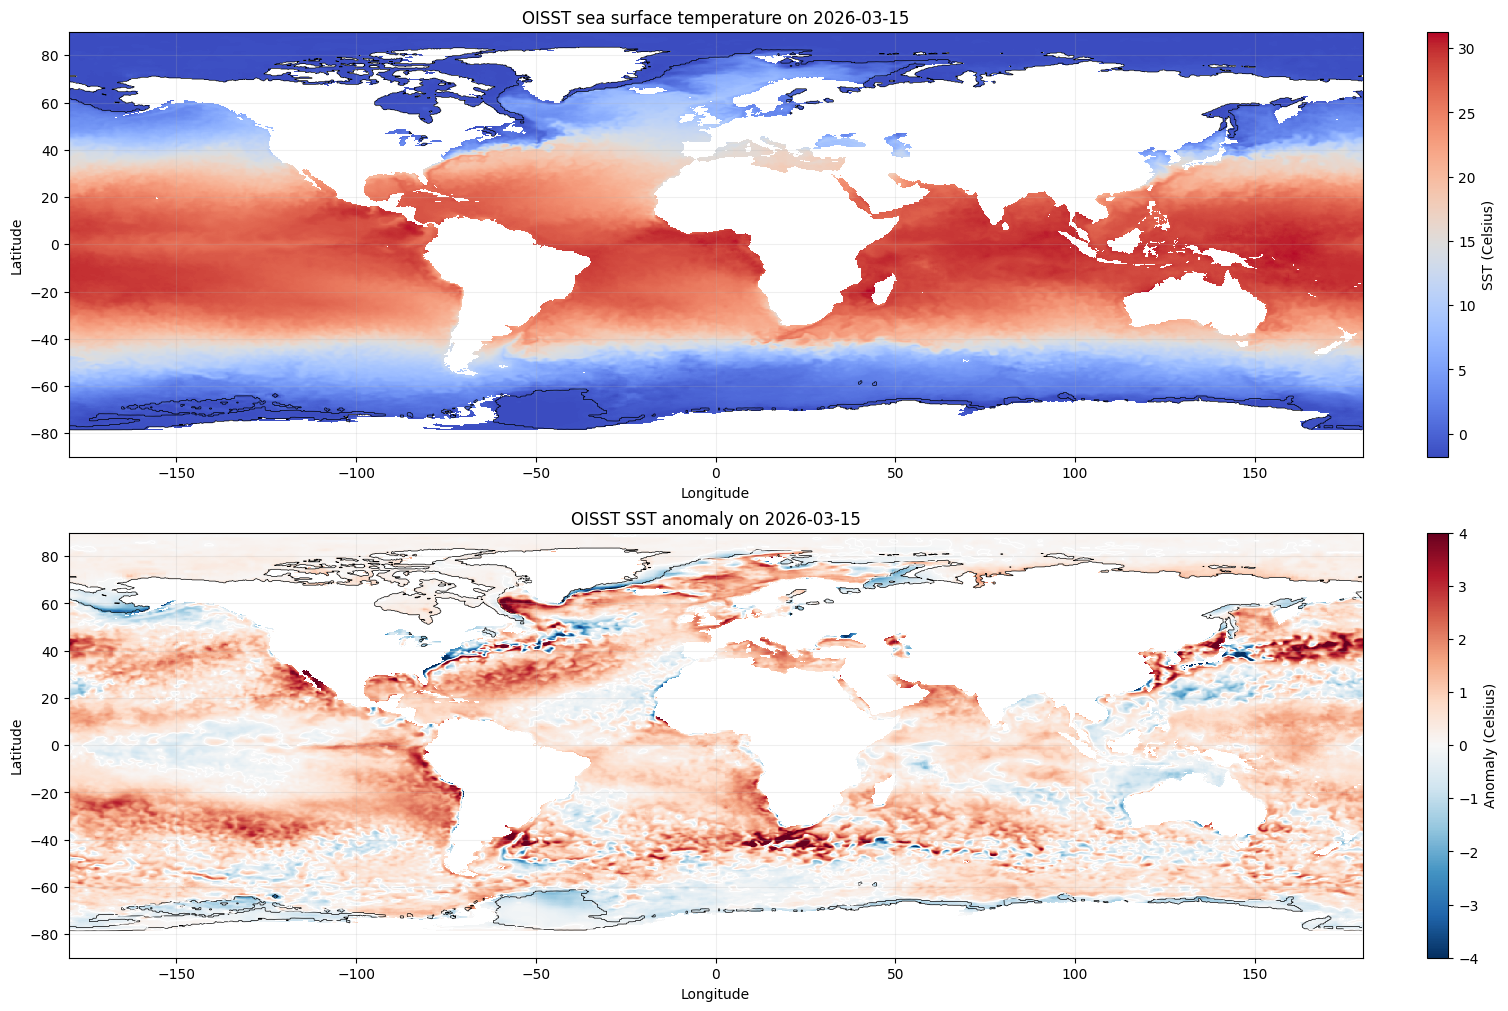

In [5]:
# Full-field maps
fig, axes = plt.subplots(2, 1, figsize=(15, 10), constrained_layout=True)

sst_plot = np.ma.masked_invalid(sst_grid)
anom_plot = np.ma.masked_invalid(anom_grid)
ice_plot = np.nan_to_num(ice_grid, nan=0.0)

pcm0 = axes[0].pcolormesh(lon_grid, lat_grid, sst_plot, cmap='coolwarm', shading='auto', rasterized=True)
axes[0].contour(lon_grid, lat_grid, ice_plot, levels=[0.15], colors='black', linewidths=0.5)
axes[0].set_title(f'OISST sea surface temperature on {date_str}')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_xlim(-180, 180)
axes[0].set_ylim(-90, 90)
axes[0].grid(alpha=0.2)
plt.colorbar(pcm0, ax=axes[0], label=f"SST ({sst_meta['units']})")

pcm1 = axes[1].pcolormesh(lon_grid, lat_grid, anom_plot, cmap='RdBu_r', vmin=-4, vmax=4,
                         shading='auto', rasterized=True)
axes[1].contour(lon_grid, lat_grid, ice_plot, levels=[0.15], colors='black', linewidths=0.5)
axes[1].contour(lon_grid, lat_grid, anom_plot, levels=[0.0], colors='white', linewidths=0.7)
axes[1].set_title(f'OISST SST anomaly on {date_str}')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_xlim(-180, 180)
axes[1].set_ylim(-90, 90)
axes[1].grid(alpha=0.2)
plt.colorbar(pcm1, ax=axes[1], label=f"Anomaly ({anom_meta['units']})")


/var/folders/w7/6nm4rxb53x55tjtr3b5k86b80000gn/T/ipykernel_5903/3943765690.py:2: RuntimeWarning: Mean of empty slice
  zonal_mean = np.nanmean(sst_grid, axis=1)


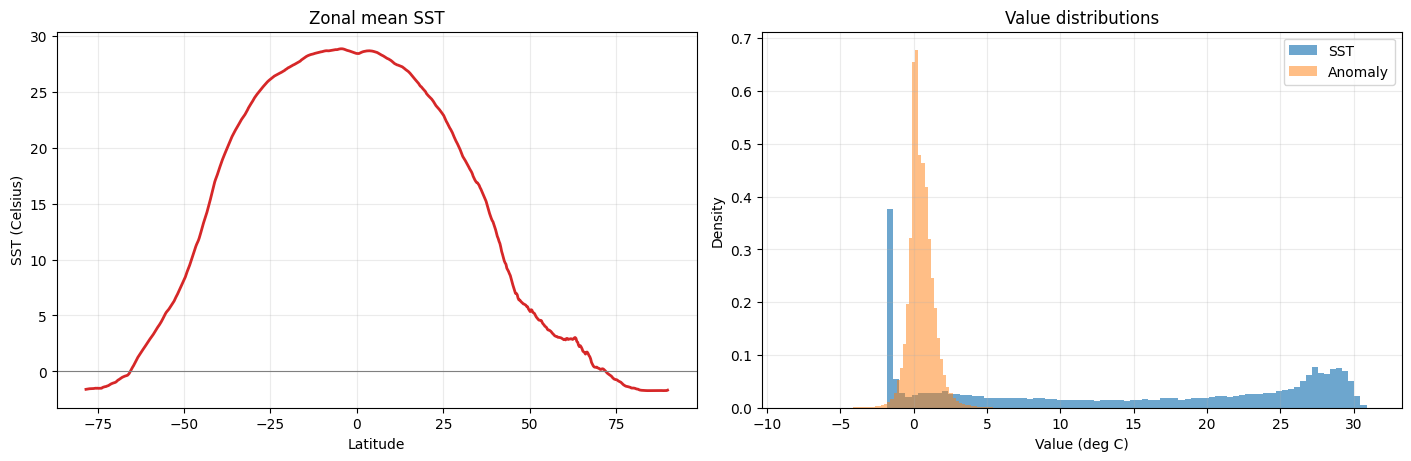

In [6]:
# Summary diagnostics
zonal_mean = np.nanmean(sst_grid, axis=1)
lat_axis = lat_grid[:, 0]
sst_vals = sst_grid[np.isfinite(sst_grid)]
anom_vals = anom_grid[np.isfinite(anom_grid)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)

axes[0].plot(lat_axis, zonal_mean, color='tab:red', linewidth=2)
axes[0].axhline(0.0, color='0.5', linewidth=0.8)
axes[0].set_title('Zonal mean SST')
axes[0].set_xlabel('Latitude')
axes[0].set_ylabel(f"SST ({sst_meta['units']})")
axes[0].grid(alpha=0.25)

axes[1].hist(sst_vals, bins=80, density=True, alpha=0.65, label='SST', color='tab:blue')
axes[1].hist(anom_vals, bins=80, density=True, alpha=0.5, label='Anomaly', color='tab:orange')
axes[1].set_title('Value distributions')
axes[1].set_xlabel('Value (deg C)')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(alpha=0.25)


In [7]:
# Load data for EFGPND
x, y = load_oisst_torch(n_sub=100_000, seed=0, path=DATASET_FILENAME)
# x, y = load_oisst_torch(seed=0, path=DATASET_FILENAME)
print(f"x shape: {x.shape}")  # (N, 2) - lon, lat
print(f"y shape: {y.shape}")  # (N,) - sea surface temperature
print(f"Lon range: {x[:,0].min():.3f} to {x[:,0].max():.3f}")
print(f"Lat range: {x[:,1].min():.3f} to {x[:,1].max():.3f}")
print(f"SST range: {y.min():.2f} to {y.max():.2f} {sst_meta['units']}")


x shape: torch.Size([100000, 2])
y shape: torch.Size([100000])
Lon range: -179.875 to 179.875
Lat range: -78.375 to 89.875
SST range: -1.80 to 31.09 Celsius


In [8]:
# # Plot the training subsample
# fig, ax = plt.subplots(figsize=(14, 5))
# sc = ax.scatter(x[:,0].numpy(), x[:,1].numpy(), c=y.numpy(), s=0.25,
#                 cmap='coolwarm', alpha=0.55, rasterized=True)
# ax.set_title('Training subsample for EFGPND')
# ax.set_xlabel('Longitude')
# ax.set_ylabel('Latitude')
# ax.set_xlim(-180, 180)
# ax.set_ylim(-90, 90)
# ax.grid(alpha=0.2)
# plt.colorbar(sc, ax=ax, label=f"SST ({sst_meta['units']})")
# plt.tight_layout()


In [9]:
# Normalize inputs to [0, 1] and standardize outputs
x_min, x_max = x.min(dim=0).values, x.max(dim=0).values
x = (x - x_min) / (x_max - x_min)

y_mean, y_std = y.mean(), y.std()
y = (y - y_mean) / y_std

print(f"x range per dim: {x.min(dim=0).values.tolist()} to {x.max(dim=0).values.tolist()}")
print(f"y mean={y.mean():.4f}, std={y.std():.4f}")


x range per dim: [0.0, 0.0] to [1.0, 1.0]
y mean=0.0000, std=1.0000


In [10]:
x = x.to(dtype=torch.float32)
y = y.to(dtype=torch.float32)

In [11]:
EPSILON = 1e-4
kernel_type = 'SquaredExponential'
cg_tol = 1e-5
noise_floor = 1e-4


In [12]:
max_iters = 50
J = 1

training_log = {
    'iter': [],
    'lengthscale': [],
    'variance': [],
    'sigmasq': [],
    'mean_cg_iters': [],
    'trace_cg_iters': [],
    'mtot': [],
    'feature_count': [],
}

model = EFGPND(x, y, kernel=kernel_type, eps=EPSILON)
optimizer = Adam(model.parameters(), lr=0.1)

for it in range(max_iters):
    optimizer.zero_grad()
    model.compute_gradients(trace_samples=J, cg_tol=cg_tol, noise_floor=noise_floor)
    optimizer.step()

    stats = model.last_gradient_stats
    mean_cg_iters = stats.get('mean_cg_iters')
    trace_cg_iters = stats.get('trace_cg_iters')
    mtot = stats.get('mtot')
    feature_count = stats.get('feature_count')

    lengthscale = model.kernel.get_hyper('lengthscale')
    variance = model.kernel.get_hyper('variance')
    sigmasq = model._gp_params.sig2.item()
    training_log['iter'].append(it)
    training_log['lengthscale'].append(lengthscale)
    training_log['variance'].append(variance)
    training_log['sigmasq'].append(sigmasq)
    training_log['mean_cg_iters'].append(mean_cg_iters)
    training_log['trace_cg_iters'].append(trace_cg_iters)
    training_log['mtot'].append(mtot)
    training_log['feature_count'].append(feature_count)

    if it % 10 == 0:
        print(
            f"iter {it:>3}  ℓ={lengthscale:.4g}  σ_f²={variance:.4g}  σ_n²={sigmasq:.4g}  "
            f"cg(mean/trace)={mean_cg_iters}/{trace_cg_iters}  mtot={mtot}  M={feature_count}"
        )

print(
    f"Final: ℓ={lengthscale:.4g}, σ_f²={variance:.4g}, σ_n²={sigmasq:.4g}, "
    f"cg(mean/trace)={mean_cg_iters}/{trace_cg_iters}, mtot={mtot}, M={feature_count}"
)


iter   0  ℓ=0.234  σ_f²=1.105  σ_n²=0.181  cg(mean/trace)=338/338  mtot=13  M=169
iter  10  ℓ=0.08925  σ_f²=2.796  σ_n²=0.06653  cg(mean/trace)=343/363  mtot=25  M=625
iter  20  ℓ=0.04341  σ_f²=3.956  σ_n²=0.02448  cg(mean/trace)=324/305  mtot=43  M=1849
iter  30  ℓ=0.03449  σ_f²=1.964  σ_n²=0.009163  cg(mean/trace)=288/306  mtot=55  M=3025
iter  40  ℓ=0.02009  σ_f²=0.7443  σ_n²=0.003645  cg(mean/trace)=340/333  mtot=83  M=6889
Final: ℓ=0.01527, σ_f²=0.2486, σ_n²=0.001727, cg(mean/trace)=284/281, mtot=111, M=12321


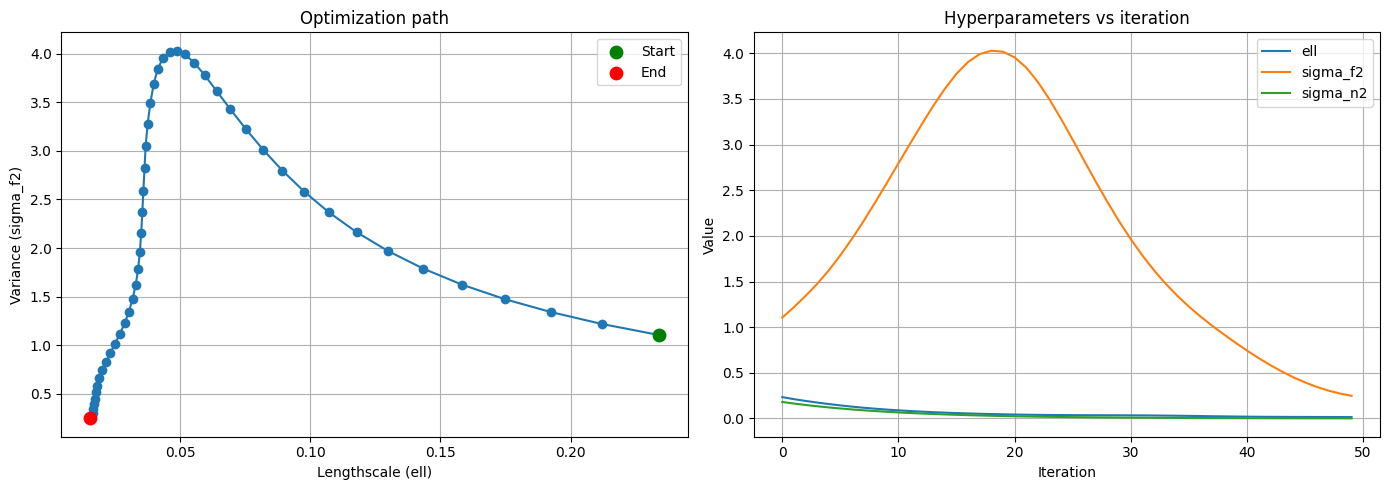

In [13]:
# Plot optimization path
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(training_log['lengthscale'], training_log['variance'], 'o-')
ax1.scatter(training_log['lengthscale'][0], training_log['variance'][0], color='green', s=80, label='Start', zorder=5)
ax1.scatter(training_log['lengthscale'][-1], training_log['variance'][-1], color='red', s=80, label='End', zorder=5)
ax1.set_xlabel('Lengthscale (ell)')
ax1.set_ylabel('Variance (sigma_f2)')
ax1.set_title('Optimization path')
ax1.legend()
ax1.grid(True)

ax2.plot(training_log['iter'], training_log['lengthscale'], label='ell')
ax2.plot(training_log['iter'], training_log['variance'], label='sigma_f2')
ax2.plot(training_log['iter'], training_log['sigmasq'], label='sigma_n2')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Value')
ax2.set_title('Hyperparameters vs iteration')
ax2.legend()
ax2.grid(True)

plt.tight_layout()


## SKI Benchmark
Fit a memory-controlled GPyTorch SKI baseline. If the helper subsamples, reuse `x_ski_benchmark` and `y_ski_benchmark` for a matched EFGPND-vs-SKI timing or accuracy comparison.

In [14]:
SKI_MAX_TRAIN_N = 10_000
SKI_MAX_ITERS = 1
SKI_GRID_SIZE = (256, 128)
# SKI_GRID_SIZE = (64, 64)
SKI_LR = 0.3


In [15]:
ski_result = fit_ski_gp(
    x,
    y,
    kernel=kernel_type,
    grid_size=SKI_GRID_SIZE,
    max_iters=SKI_MAX_ITERS,
    lr=SKI_LR,
    noise_floor=noise_floor,
    max_train_n=SKI_MAX_TRAIN_N,
    subsample_seed=0,
    cg_tolerance=1,
    max_cg_iterations=1000,
    max_preconditioner_size=10,
    max_lanczos_quadrature_iterations=10,
    num_trace_samples=2,
    use_toeplitz=True,
    memory_efficient=True,
    verbose=True,
)

ski_history = ski_result['history']
ski_train_indices = ski_result['train_indices']
if ski_train_indices is None:
    x_ski_benchmark = x
    y_ski_benchmark = y
else:
    ski_train_indices_device = ski_train_indices.to(x.device)
    x_ski_benchmark = x.index_select(0, ski_train_indices_device)
    y_ski_benchmark = y.index_select(0, ski_train_indices_device)

ski_iter_sec = np.array(ski_history['forward_sec']) + np.array(ski_history['backward_sec'])
print(f"SKI benchmark points: {ski_result['num_train']:,} / {ski_result['num_total']:,}")
print(f"SKI grid size: {ski_result['grid_size']}")
print(f"SKI best loss: {ski_result['best_loss']:.6f} at iter {ski_result['best_iteration']}")
print(f"Mean SKI hyper-step time: {ski_iter_sec.mean():.2f}s")
print('Use x_ski_benchmark and y_ski_benchmark for a matched EFGPND-vs-SKI rerun.')


/Users/colecitrenbaum/myenv/lib/python3.13/site-packages/linear_operator/utils/sparse.py:51: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  if nonzero_indices.storage():
/Users/colecitrenbaum/myenv/lib/python3.13/site-packages/linear_operator/utils/sparse.py:66: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:646.)
  res = cls(index_tensor, value_tensor, interp_size)


[SKI] iter   1/1  loss=1.34727  ls=0.554355  os=0.854355  noise=0.854455  time(fwd/bwd)=1.32/0.81s  rss=1.486 GB
SKI benchmark points: 10,000 / 100,000
SKI grid size: (256, 128)
SKI best loss: 1.347269 at iter 1
Mean SKI hyper-step time: 2.13s
Use x_ski_benchmark and y_ski_benchmark for a matched EFGPND-vs-SKI rerun.


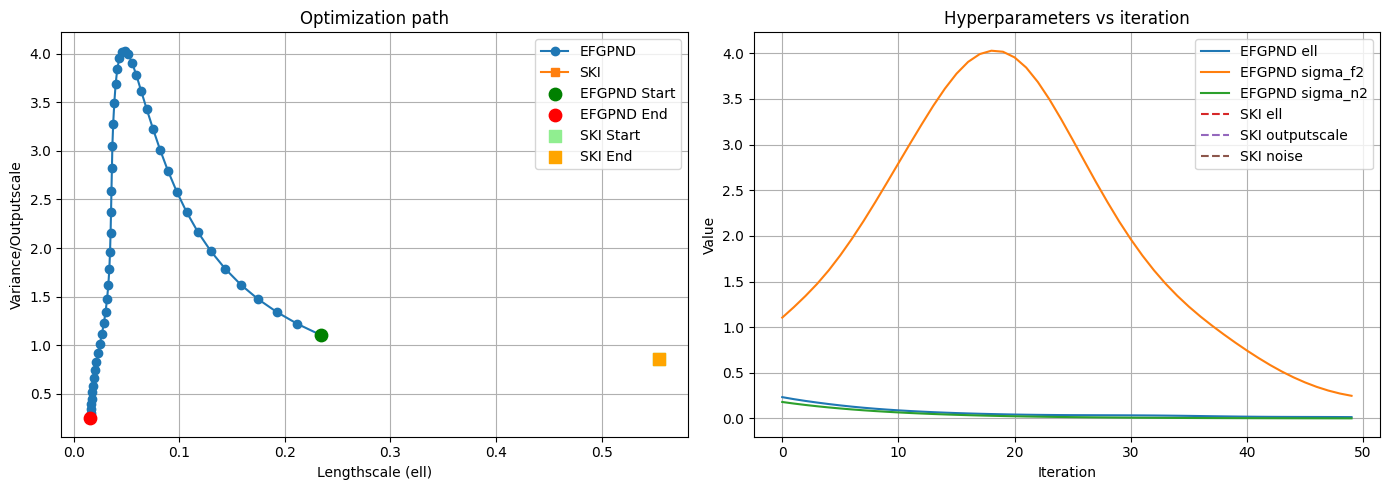

In [16]:
# Plot optimization path
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(training_log['lengthscale'], training_log['variance'], 'o-', label='EFGPND')
ax1.plot(ski_history['lengthscale'], ski_history['outputscale'], 's-', label='SKI')
ax1.scatter(training_log['lengthscale'][0], training_log['variance'][0], color='green', s=80, label='EFGPND Start', zorder=5)
ax1.scatter(training_log['lengthscale'][-1], training_log['variance'][-1], color='red', s=80, label='EFGPND End', zorder=5)
ax1.scatter(ski_history['lengthscale'][0], ski_history['outputscale'][0], color='lightgreen', s=80, marker='s', label='SKI Start', zorder=5)
ax1.scatter(ski_history['lengthscale'][-1], ski_history['outputscale'][-1], color='orange', s=80, marker='s', label='SKI End', zorder=5)
ax1.set_xlabel('Lengthscale (ell)')
ax1.set_ylabel('Variance/Outputscale')
ax1.set_title('Optimization path')
ax1.legend()
ax1.grid(True)

ax2.plot(training_log['iter'], training_log['lengthscale'], label='EFGPND ell')
ax2.plot(training_log['iter'], training_log['variance'], label='EFGPND sigma_f2')
ax2.plot(training_log['iter'], training_log['sigmasq'], label='EFGPND sigma_n2')
ax2.plot(ski_history['iteration'], ski_history['lengthscale'], '--', label='SKI ell')
ax2.plot(ski_history['iteration'], ski_history['outputscale'], '--', label='SKI outputscale')
ax2.plot(ski_history['iteration'], ski_history['noise'], '--', label='SKI noise')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Value')
ax2.set_title('Hyperparameters vs iteration')
ax2.legend()
ax2.grid(True)

plt.tight_layout()


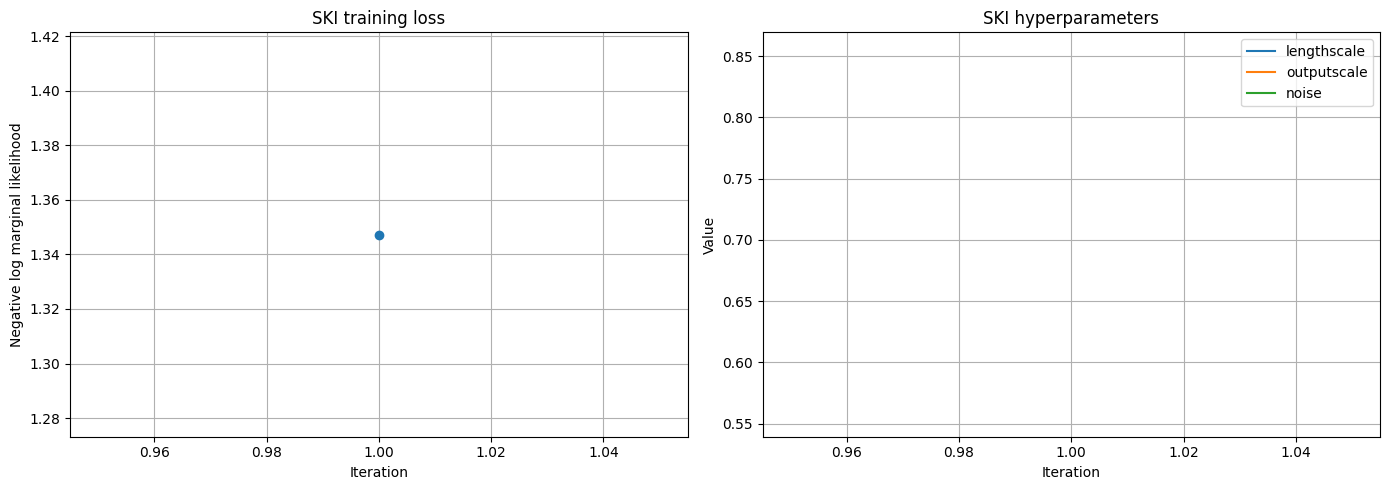

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(ski_history['iteration'], ski_history['loss'], 'o-')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Negative log marginal likelihood')
ax1.set_title('SKI training loss')
ax1.grid(True)

ax2.plot(ski_history['iteration'], ski_history['lengthscale'], label='lengthscale')
ax2.plot(ski_history['iteration'], ski_history['outputscale'], label='outputscale')
ax2.plot(ski_history['iteration'], ski_history['noise'], label='noise')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Value')
ax2.set_title('SKI hyperparameters')
ax2.legend()
ax2.grid(True)

plt.tight_layout()


In [18]:
# Predict posterior mean on a global grid
grid_res_lon = 240
grid_res_lat = 120
g_lon = torch.linspace(0, 1, grid_res_lon, dtype=x.dtype)
g_lat = torch.linspace(0, 1, grid_res_lat, dtype=x.dtype)
G_LON, G_LAT = torch.meshgrid(g_lon, g_lat, indexing='ij')
x_new = torch.stack([G_LON.flatten(), G_LAT.flatten()], dim=1)

mean_pred = model.predict(x_new=x_new, return_variance=False)
mean_pred = mean_pred[0] if isinstance(mean_pred, tuple) else mean_pred

mean_grid = (mean_pred.detach().cpu() * y_std + y_mean).numpy().reshape(grid_res_lon, grid_res_lat)
lon_pred = (G_LON.numpy() * (x_max[0] - x_min[0]).item() + x_min[0].item())
lat_pred = (G_LAT.numpy() * (x_max[1] - x_min[1]).item() + x_min[1].item())

# Mask posterior values over land using the native OISST validity mask.
lon_axis = lon_grid[0, :]
lat_axis = lat_grid[:, 0]
lon_step = lon_axis[1] - lon_axis[0]
lat_step = lat_axis[1] - lat_axis[0]
lon_idx = np.clip(np.rint((lon_pred - lon_axis[0]) / lon_step).astype(int), 0, len(lon_axis) - 1)
lat_idx = np.clip(np.rint((lat_pred - lat_axis[0]) / lat_step).astype(int), 0, len(lat_axis) - 1)
ocean_mask_pred = valid_sst[lat_idx, lon_idx]
mean_grid_masked = np.ma.masked_where(~ocean_mask_pred, mean_grid)


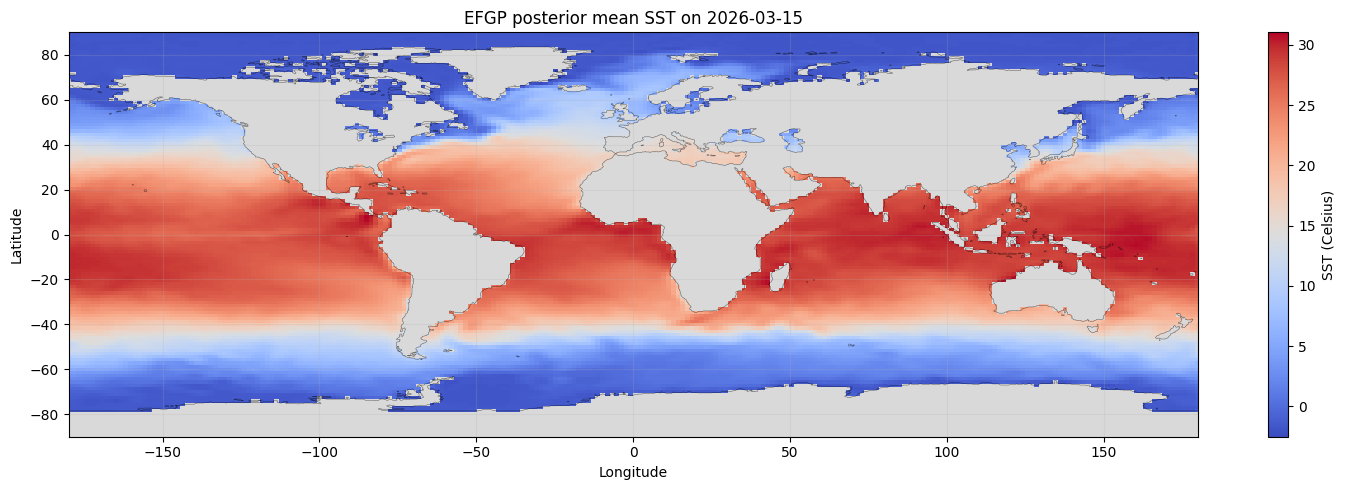

In [20]:
# Plot posterior mean
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_facecolor('#d9d9d9')
pcm = ax.pcolormesh(lon_pred, lat_pred, mean_grid_masked, cmap='coolwarm', shading='auto', rasterized=True)
ax.contour(lon_grid, lat_grid, valid_sst.astype(float), levels=[0.5], colors='black', linewidths=0.35, alpha=0.6)
ax.set_title(f'EFGP posterior mean SST on {date_str}')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.grid(alpha=0.2)
plt.colorbar(pcm, ax=ax, label=f"SST ({sst_meta['units']})")
plt.tight_layout()
